# Introduction to Symbolic Regression


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(7)


## <span style="color:Orange">Helper Functions</span>


In [33]:
@dataclass
class SymbolicModel:
    selected_names: list
    selected_idx: list
    intercept: float
    coef: np.ndarray
    mse: float
    bic: float


def build_design_matrix(var_dict, library):
    columns = []
    names = []
    for name, fn in library:
        column = np.asarray(fn(var_dict), dtype=float).reshape(-1)
        columns.append(column)
        names.append(name)
    return np.column_stack(columns), names


def fit_linear_model(Phi, y):
    Phi_aug = np.column_stack([np.ones(len(Phi)), Phi])
    params, *_ = np.linalg.lstsq(Phi_aug, y, rcond=None)
    y_pred = Phi_aug @ params
    intercept = float(params[0])
    coef = params[1:]
    return intercept, coef, y_pred


def bic_score(y_true, y_pred, n_params):
    mse = np.mean((y_true - y_pred) ** 2)
    mse = max(float(mse), 1e-14)
    bic = len(y_true) * np.log(mse) + n_params * np.log(len(y_true))
    return mse, float(bic)


def fit_symbolic_regression(var_dict, y, library, max_terms=4, min_improvement=2.0):
    Phi, names = build_design_matrix(var_dict, library)
    y = np.asarray(y, dtype=float).reshape(-1)

    selected = []
    selected_names = []
    remaining = list(range(Phi.shape[1]))

    baseline = np.full_like(y, y.mean())
    best_mse, best_bic = bic_score(y, baseline, n_params=1)
    best_intercept = float(y.mean())
    best_coef = np.array([])

    for _ in range(max_terms):
        candidate_best = None
        for idx in remaining:
            cols = selected + [idx]
            intercept, coef, y_pred = fit_linear_model(Phi[:, cols], y)
            mse, bic = bic_score(y, y_pred, n_params=len(cols) + 1)
            if candidate_best is None or bic < candidate_best['bic']:
                candidate_best = {
                    'idx': idx,
                    'intercept': intercept,
                    'coef': coef,
                    'mse': mse,
                    'bic': bic,
                }

        if candidate_best is None:
            break
        if best_bic - candidate_best['bic'] < min_improvement:
            break

        selected.append(candidate_best['idx'])
        selected_names.append(names[candidate_best['idx']])
        remaining.remove(candidate_best['idx'])
        best_intercept = candidate_best['intercept']
        best_coef = candidate_best['coef']
        best_mse = candidate_best['mse']
        best_bic = candidate_best['bic']

    return SymbolicModel(
        selected_names=selected_names,
        selected_idx=selected,
        intercept=best_intercept,
        coef=np.asarray(best_coef, dtype=float),
        mse=best_mse,
        bic=best_bic,
    )


def predict_symbolic_model(model, var_dict, library):
    Phi, _ = build_design_matrix(var_dict, library)
    if len(model.selected_idx) == 0:
        return np.full(Phi.shape[0], model.intercept)
    return model.intercept + Phi[:, model.selected_idx] @ model.coef


def format_equation(model, target='y', precision=4):
    pieces = [f"{target} = {model.intercept:.{precision}g}"]
    for coeff, name in zip(model.coef, model.selected_names):
        sign = '+' if coeff >= 0 else '-'
        pieces.append(f" {sign} {abs(coeff):.{precision}g}*{name}")
    return ''.join(pieces)


def summarize_model(model, target='y'):
    print(format_equation(model, target=target))
    print(f"MSE = {model.mse:.4e}")
    print(f"BIC = {model.bic:.2f}")


def compare_fit(ax, x, y_true, y_pred, xlabel, ylabel, title):
    ax.scatter(x, y_true, s=18, alpha=0.7, label='data')
    order = np.argsort(x)
    ax.plot(x[order], y_pred[order], color='crimson', linewidth=2.5, label='symbolic fit')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()


## <span style="color:Orange">Brief Overview</span>

Symbolic regression searches for an explicit mathematical expression that maps inputs to outputs. Unlike ordinary regression, where we pick a fixed model class and only fit its parameters, symbolic regression tries to discover both the structure of the equation and the numerical coefficients.

That makes it especially attractive in physics, where we often care about interpretable laws rather than only predictive accuracy. A good symbolic model can suggest conservation laws, constitutive relations, scaling behavior, or reduced-order descriptions of a system.

In production workflows, symbolic regression is often performed with genetic programming, Monte Carlo tree search, differentiable expression search, or sparse equation discovery. In this lecture, we use a lighter approach that runs in a plain notebook: we build a library of candidate terms and then greedily select the ones that improve a model-selection score.


### <span style="color:LightGreen">Mathematical Formulation</span>

We assume that the target can be approximated by a sparse combination of candidate basis functions,

$$ \Large
y(\mathbf{x}) \approx c_0 + \sum_{k=1}^{K} c_k \, \phi_k(\mathbf{x}),
$$

where the library terms $\phi_k$ might include powers, trigonometric functions, inverse powers, exponentials, or domain-specific combinations suggested by the physics.

The approach we take in this notebook uses a forward-selection strategy:

1. Start with a constant model.
2. Try adding each candidate term one at a time.
3. Refit the coefficients with least squares.
4. Keep the term that most improves the Bayesian information criterion (BIC).
5. Stop when adding more structure is no longer justified.

This is not the only way to do symbolic regression, but it captures an important idea: in scientific modeling we want the simplest equation that still explains the data well.


### <span style="color:LightGreen">A Lightweight Symbolic Regression Engine</span>

The code below defines small libraries of candidate terms and uses the helper functions above to select a compact symbolic model. Because the search is explicit, it is easy to inspect what the algorithm is doing and to connect the result back to the physics.


In [34]:
def print_library(library):
    print('Candidate terms:')
    for name, _ in library:
        print('  ', name)


## <span style="color:Orange">Physics-Guided Shortcuts Before Search</span>

A recurring theme in physics-flavored symbolic regression is that we often do not search blindly over all algebraic expressions. Instead, we use physical structure to simplify the problem first. Two especially useful ideas are:

1. _<span style="color:Violet">Dimensional analysis</span>_: only consider combinations of variables with the right units.
2. _<span style="color:Violet">Symmetry</span>_: rewrite the problem in variables that respect invariances, such as relative coordinates instead of absolute positions.

This is one of the most useful ideas in symbolic regression workflows such as the [AI Feynman algorithm](https://www.science.org/doi/10.1126/sciadv.aay2631) created by Max Tegmark and Silviu Udrescu: physics can dramatically shrink the symbolic search space before any optimizer starts combining terms.


### <span style="color:LightGreen">Dimensional Analysis</span>

Physical quantities have units associated with them (e.g. Force is measured in Newtons, Speed in meters per second). When we have data with various units and know what units the answer takes we can analyze the combinations of units to see what answers make sense. 

For example if we measure the <span style="color:Violet">voltage</span>[$kg~m^2s^{-3}A^{-1}$] drop across a wire as well as the <span style="color:Violet">current</span>[$A$], <span style="color:Violet">resistance</span>[$kg~m^2s^{-3}A^{-2}$], <span style="color:Violet">temperature</span>[$K$], <span style="color:Violet">mass</span>[$kg$], and <span style="color:Violet">length</span>[$m$] of the wire, can we figure out what combination gives us the voltage?

We can use linear algebra to build an algorithm to do dimensional analysis for us. Let's first create a dataframe (a matrix with labels) where we can keep track of the units of various physical quantities.

In [35]:
import pandas as pd
import numpy as np
from scipy import linalg

units = {
    'Variable':['F','m','a','V','I','R','U','k','x1','x2','vx','vy','K'],
    'Units'   :['Force','Mass','Acceleration','Voltage','Current','Resistance','Energy',
                'Spring Constant','Length','Length','Speed','Speed','Energy'],
    'm'       :[1,0,1,2,0,2,2,0,1,1,1,1,2],
    's'       :[-2,0,-2,-3,0,-3,-2,-2,0,0,-1,-1,-2],
    'kg'      :[1,1,0,1,0,1,1,1,0,0,0,0,1],
    'Amp'     :[0,0,0,-1,1,-2,0,0,0,0,0,0,0]}

# Here we create a dataframe from a python dictionary. This allows us to call the entries by row or by name.
df_units=pd.DataFrame(data=units)
df_units

,Variable,Units,m,s,kg,Amp
0,F,Force,1,-2,1,0
1,m,Mass,0,0,1,0
2,a,Acceleration,1,-2,0,0
3,V,Voltage,2,-3,1,-1
4,I,Current,0,0,0,1
5,R,Resistance,2,-3,1,-2
6,U,Energy,2,-2,1,0
7,k,Spring Constant,0,-2,1,0
8,x1,Length,1,0,0,0
9,x2,Length,1,0,0,0


We can see that for example the values in the row corresponding to force are the sum of the rows for mass and acceleration. By keeping track of the appropriate powers of SI Units for our physical quantities, dimensional analysis for a target quantity reduces to the linear algebra problem of finding which vector of integers will reproduce the target row when multiplying the input rows.

For example, we can see that <span style="color:Violet">Force</span> has the units of <span style="color:Violet">mass</span>$\times$<span style="color:Violet">acceleration</span> because 

$$ \Large
1*\begin{pmatrix}0\\0\\1\\0\end{pmatrix}+1*\begin{pmatrix}1\\-2\\0\\0\end{pmatrix}=\begin{pmatrix}1\\-2\\1\\0\end{pmatrix}
$$

#### <span style="color:Pink">Example: Ohm's Law</span>

Suppose we want to recover [Ohm's law](https://en.wikipedia.org/wiki/Ohm%27s_law). If the target quantity is voltage and the candidate inputs are current, resistance, and mass, dimensional analysis already tells us that only one simple combination is plausible: $V \propto IR$. That means symbolic regression does not need to waste time testing dimensionally inconsistent expressions such as $V \propto I + m$.


In [36]:
from itertools import product

def find_dimensional_matches(input_units, target_units, exponent_range=range(-3, 4)):
    names = list(input_units.keys())
    target = np.asarray(target_units, dtype=int)
    matches = []

    for exponents in product(exponent_range, repeat=len(names)):
        if all(e == 0 for e in exponents):
            continue
        total = np.zeros_like(target)
        for name, exponent in zip(names, exponents):
            total = total + exponent * np.asarray(input_units[name], dtype=int)
        if np.array_equal(total, target):
            matches.append(dict(zip(names, exponents)))
    return matches

def format_dimensional_match(match):
    pieces = []
    for name, exponent in match.items():
        if exponent == 0:
            continue
        if exponent == 1:
            pieces.append(name)
        else:
            pieces.append(f'{name}^{exponent}')
    return ' * '.join(pieces)

In [37]:
# Unit vectors are ordered as [kg, m, s, A]
units = {
    'V': np.array([1, 2, -3, -1]),
    'I': np.array([0, 0, 0, 1]),
    'R': np.array([1, 2, -3, -2]),
    'm': np.array([1, 0, 0, 0]),
}

matches = find_dimensional_matches(
    {'I': units['I'], 'R': units['R'], 'm': units['m']},
    units['V'],
    exponent_range=range(-2, 3),
)

print('Dimensionally valid monomial combinations for voltage:')
for match in matches:
    print('  V ~', format_dimensional_match(match))


Dimensionally valid monomial combinations for voltage:
  V ~ I * R


### <span style="color:LightGreen">Symmetry Example</span>

Now consider spring potential energy,

$$ \Large
U(x_1, x_2) = \frac{1}{2} k (x_1 - x_2)^2.
$$

This system has translation symmetry: if we shift both positions by the same amount, the potential energy does not change. That suggests a better coordinate choice than $(x_1, x_2)$ individually. The physically meaningful variable is the relative displacement $\Delta x = x_1 - x_2$.


In [38]:

def translation_invariance_error(fn, x1, x2, shifts):
    base = fn(x1, x2)
    shifted = fn(x1 + shifts, x2 + shifts)
    return np.sqrt(np.mean((base - shifted) ** 2))

Translation-invariance RMSE after shifting both coordinates equally: 0.00e+00
U(dx) = -0.005973 + 0.9016*dx^2
MSE = 5.6935e-03
BIC = -610.64
Expected quadratic coefficient: 0.9000


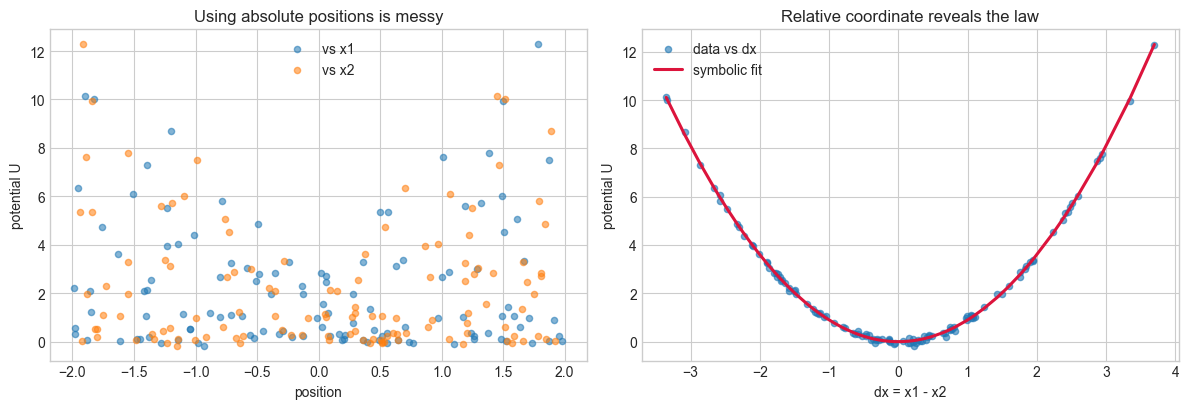

In [39]:
k_sym = 1.8
x1_sym = rng.uniform(-2.0, 2.0, size=120)
x2_sym = rng.uniform(-2.0, 2.0, size=120)
dx_sym = x1_sym - x2_sym
U_sym = 0.5 * k_sym * dx_sym**2 + rng.normal(scale=0.08, size=dx_sym.shape)

shift = 0.75 * np.ones_like(x1_sym)
symmetry_rmse = translation_invariance_error(
    lambda a, b: 0.5 * k_sym * (a - b) ** 2,
    x1_sym,
    x2_sym,
    shift,
)

library_relative = [
    ('dx', lambda v: v['dx']),
    ('dx^2', lambda v: v['dx']**2),
    ('dx^3', lambda v: v['dx']**3),
]

model_relative = fit_symbolic_regression({'dx': dx_sym}, U_sym, library_relative, max_terms=3)
U_pred_relative = predict_symbolic_model(model_relative, {'dx': dx_sym}, library_relative)

print(f'Translation-invariance RMSE after shifting both coordinates equally: {symmetry_rmse:.2e}')
summarize_model(model_relative, target='U(dx)')
print(f'Expected quadratic coefficient: {0.5 * k_sym:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(x1_sym, U_sym, s=20, alpha=0.55, label='vs x1')
axes[0].scatter(x2_sym, U_sym, s=20, alpha=0.55, label='vs x2')
axes[0].set_title('Using absolute positions is messy')
axes[0].set_xlabel('position')
axes[0].set_ylabel('potential U')
axes[0].legend()

order = np.argsort(dx_sym)
axes[1].scatter(dx_sym, U_sym, s=20, alpha=0.6, label='data vs dx')
axes[1].plot(dx_sym[order], U_pred_relative[order], color='crimson', linewidth=2.2, label='symbolic fit')
axes[1].set_title('Relative coordinate reveals the law')
axes[1].set_xlabel('dx = x1 - x2')
axes[1].set_ylabel('potential U')
axes[1].legend()

plt.tight_layout()
plt.show()


## <span style="color:Orange">Example: Constant Acceleration</span>

For one-dimensional motion with constant acceleration, the position is

$$ \Large
x(t) = x_0 + v_0 t + \frac{1}{2} a t^2.
$$

If the data come from free fall, we expect the symbolic regressor to prefer a sparse quadratic model over more complicated alternatives.


Candidate terms:
   t
   t^2
   t^3
   t^4

x(t) = 1.232 + 6.721*t - 4.926*t^2
MSE = 2.7637e-02
BIC = -416.27
Expected quadratic coefficient: -4.9050


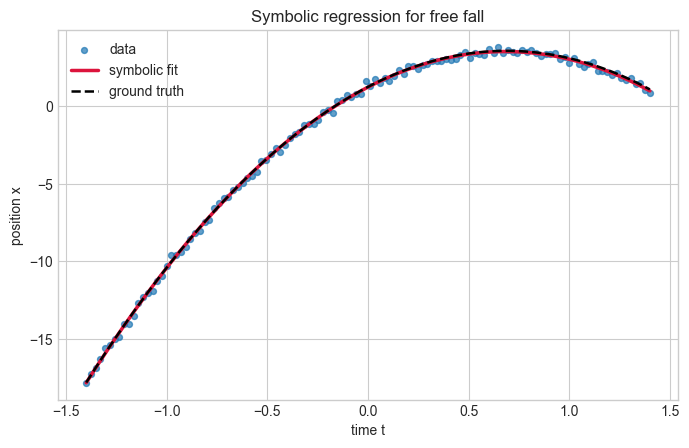

In [40]:
x0 = 1.25
v0 = 6.75
g = 9.81

t = np.linspace(-1.4, 1.4, 120)
x_true = x0 + v0 * t - 0.5 * g * t**2
x_obs = x_true + rng.normal(scale=0.18, size=t.shape)

library_kinematics = [
    ('t', lambda v: v['t']),
    ('t^2', lambda v: v['t']**2),
    ('t^3', lambda v: v['t']**3),
    ('t^4', lambda v: v['t']**4),
]

model_kinematics = fit_symbolic_regression({'t': t}, x_obs, library_kinematics, max_terms=4)
x_pred = predict_symbolic_model(model_kinematics, {'t': t}, library_kinematics)

print_library(library_kinematics)
print()
summarize_model(model_kinematics, target='x(t)')
print(f'Expected quadratic coefficient: {-0.5 * g:.4f}')

fig, ax = plt.subplots(figsize=(8, 4.8))
compare_fit(ax, t, x_obs, x_pred, 'time t', 'position x', 'Symbolic regression for free fall')
ax.plot(t, x_true, color='black', linestyle='--', linewidth=1.8, label='ground truth')
ax.legend()
plt.show()


## <span style="color:Orange">Example: Restoring Force in an Anharmonic Oscillator</span>

A pure Hooke's-law spring has $F(x) = -kx$, but many physical systems pick up nonlinear corrections. A common toy model is

$$ \Large
F(x) = -k x - \alpha x^3,
$$

which appears in [Duffing-style oscillators](https://en.wikipedia.org/wiki/Duffing_equation) and weakly nonlinear restoring forces. Here we ask the symbolic regressor to discover that the cubic correction matters.


Candidate terms:
   x
   x^2
   x^3
   x^5
F(x) = -0.01477 - 2.429*x - 0.7318*x^3
MSE = 1.3716e-02
BIC = -500.34
Expected linear coefficient: -2.4000
Expected cubic coefficient: -0.7500


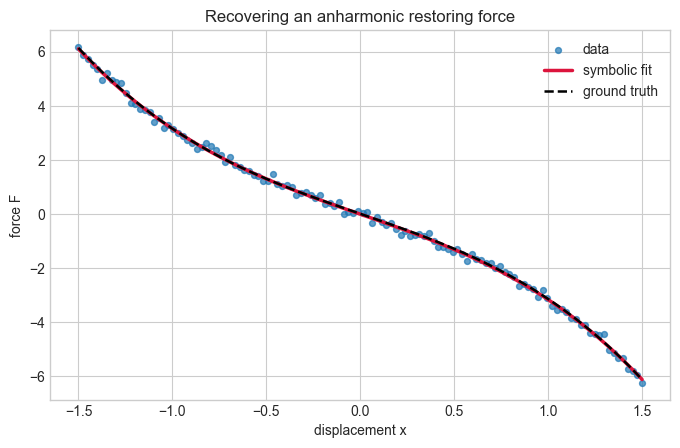

In [43]:
k = 2.4
alpha = 0.75

x = np.linspace(-1.5, 1.5, 120)
force_true = -k * x - alpha * x**3
force_obs = force_true + rng.normal(scale=0.12, size=x.shape)

library_force = [
    ('x', lambda v: v['x']),
    ('x^2', lambda v: v['x']**2),
    ('x^3', lambda v: v['x']**3),
    ('x^5', lambda v: v['x']**5),
]

model_force = fit_symbolic_regression({'x': x}, force_obs, library_force, max_terms=4)
force_pred = predict_symbolic_model(model_force, {'x': x}, library_force)
print_library(library_force)

summarize_model(model_force, target='F(x)')
print(f'Expected linear coefficient: {-k:.4f}')
print(f'Expected cubic coefficient: {-alpha:.4f}')

fig, ax = plt.subplots(figsize=(8, 4.8))
compare_fit(ax, x, force_obs, force_pred, 'displacement x', 'force F', 'Recovering an anharmonic restoring force')
ax.plot(x, force_true, color='black', linestyle='--', linewidth=1.8, label='ground truth')
ax.legend()
plt.show()


## <span style="color:Orange">Example: An Inverse-Square Law</span>

Inverse-power laws are everywhere in physics. As a simple example, suppose we observe a force that depends on distance like

$$ \Large
F(r) = \frac{C}{r^2}.
$$

This could represent a toy gravitational or electrostatic interaction in convenient units. A symbolic regressor should prefer the $r^{-2}$ term when the library contains several competing powers.


Candidate terms:
   r
   1/r
   1/r^2
   1/r^3
   log(r)
F(r) = -0.00431 + 3.612*1/r^2
MSE = 9.0101e-04
BIC = -831.86
Expected inverse-square coefficient: 3.6000


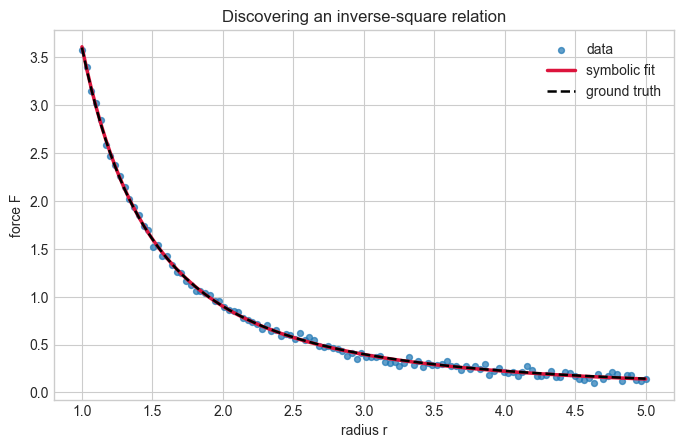

In [45]:
C = 3.6

r = np.linspace(1.0, 5.0, 120)
force_true_inv = C / r**2
force_obs_inv = force_true_inv + rng.normal(scale=0.03, size=r.shape)

library_inverse = [
    ('r', lambda v: v['r']),
    ('1/r', lambda v: 1.0 / v['r']),
    ('1/r^2', lambda v: 1.0 / v['r']**2),
    ('1/r^3', lambda v: 1.0 / v['r']**3),
    ('log(r)', lambda v: np.log(v['r'])),
]

model_inverse = fit_symbolic_regression({'r': r}, force_obs_inv, library_inverse, max_terms=4)
force_pred_inv = predict_symbolic_model(model_inverse, {'r': r}, library_inverse)

print_library(library_inverse)
summarize_model(model_inverse, target='F(r)')
print(f'Expected inverse-square coefficient: {C:.4f}')

fig, ax = plt.subplots(figsize=(8, 4.8))
compare_fit(ax, r, force_obs_inv, force_pred_inv, 'radius r', 'force F', 'Discovering an inverse-square relation')
ax.plot(r, force_true_inv, color='black', linestyle='--', linewidth=1.8, label='ground truth')
ax.legend()
plt.show()


## <span style="color:Orange">Neural Networks for Symbolic Regression</span>

A neural network can act as a flexible surrogate model before symbolic regression is applied. This is useful when the measurements are sparse or noisy: the network first learns a smooth approximation to the underlying function, and then we run symbolic regression on the network predictions instead of directly on the raw observations.

This hybrid workflow is often called <span style="color:Violet">symbolic distillation</span>. It is not fully end-to-end symbolic regression, but it is a practical scientific pattern:

1. Fit a neural network to the data.
2. Sample the neural network on a dense grid.
3. Recover a compact symbolic law from the neural surrogate.

Below we revisit the anharmonic restoring-force example with but this time with fewer, noisier measurements. We compare a symbolic fit to the raw data against a symbolic fit distilled from a neural network.


Candidate terms:
   x
   x^2
   x^3
Raw symbolic fit:
F(x) = -0.05361 - 2.485*x - 0.7094*x^3
MSE = 1.1561e-01
BIC = -30.16

Neural-distilled symbolic fit:
F(x) = -0.008211 - 2.421*x - 0.7456*x^3
MSE = 1.3434e-01
BIC = -465.34

MSE of raw symbolic fit vs. true dense curve: 3.9546e-03
MSE of neural-distilled symbolic fit vs. true dense curve: 2.4563e-04


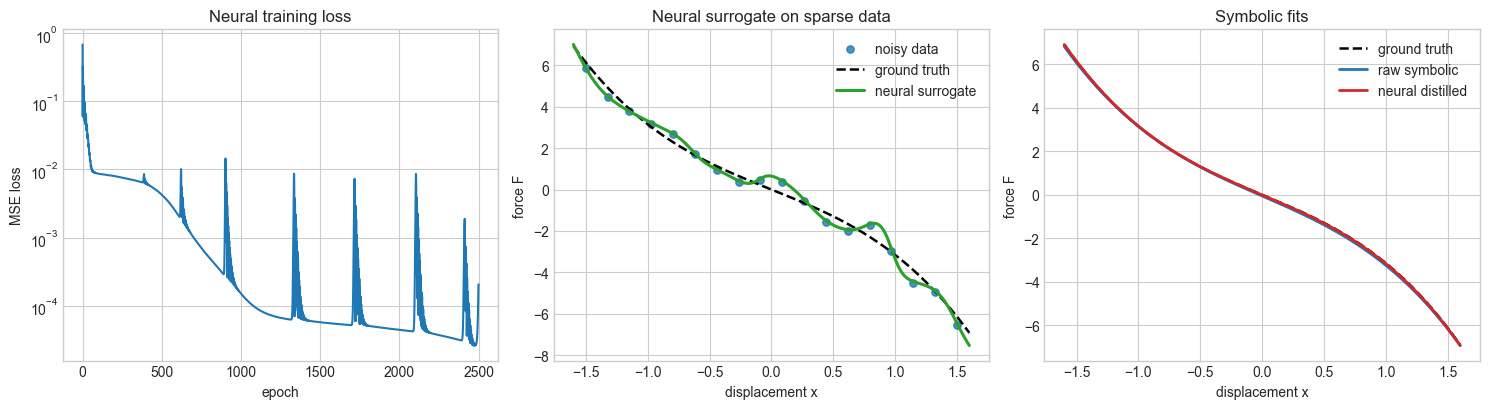

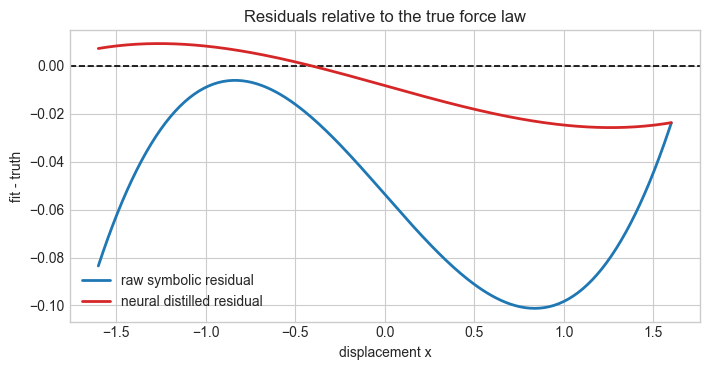

In [46]:
import torch
import torch.nn as nn

torch.manual_seed(7)


class NeuralRegressor(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_neural_regressor(x_train, y_train, hidden=64, epochs=2500, lr=1e-2):
    x_train = np.asarray(x_train, dtype=np.float32).reshape(-1, 1)
    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)

    x_mean = float(x_train.mean())
    x_std = float(x_train.std())
    y_mean = float(y_train.mean())
    y_std = float(y_train.std())

    x_scaled = (x_train - x_mean) / (x_std + 1e-6)
    y_scaled = (y_train - y_mean) / (y_std + 1e-6)

    x_tensor = torch.tensor(x_scaled)
    y_tensor = torch.tensor(y_scaled)

    model = NeuralRegressor(hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []

    for _ in range(epochs):
        optimizer.zero_grad()
        prediction = model(x_tensor)
        loss = loss_fn(prediction, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))

    return {
        'model': model.eval(),
        'x_mean': x_mean,
        'x_std': x_std,
        'y_mean': y_mean,
        'y_std': y_std,
        'losses': losses,
    }


def predict_neural_regressor(bundle, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float32).reshape(-1, 1)
    x_scaled = (x_eval - bundle['x_mean']) / (bundle['x_std'] + 1e-6)
    with torch.no_grad():
        pred_scaled = bundle['model'](torch.tensor(x_scaled)).cpu().numpy().reshape(-1)
    return pred_scaled * (bundle['y_std'] + 1e-6) + bundle['y_mean']


rng_nn = np.random.default_rng(5)
x_sparse = np.linspace(-1.5, 1.5, 18)
force_true_sparse = -k * x_sparse - alpha * x_sparse**3
force_obs_sparse = force_true_sparse + rng_nn.normal(scale=0.35, size=x_sparse.shape)

library_force_nn = [
    ('x', lambda v: v['x']),
    ('x^2', lambda v: v['x']**2),
    ('x^3', lambda v: v['x']**3),
]

raw_symbolic_model = fit_symbolic_regression(
    {'x': x_sparse}, force_obs_sparse, library_force_nn, max_terms=2
)

nn_bundle = train_neural_regressor(x_sparse, force_obs_sparse)
x_dense = np.linspace(-1.6, 1.6, 240)
force_true_dense = -k * x_dense - alpha * x_dense**3
force_nn_dense = predict_neural_regressor(nn_bundle, x_dense)

distilled_symbolic_model = fit_symbolic_regression(
    {'x': x_dense}, force_nn_dense, library_force_nn, max_terms=2
)

force_raw_symbolic = predict_symbolic_model(raw_symbolic_model, {'x': x_dense}, library_force_nn)
force_distilled_symbolic = predict_symbolic_model(distilled_symbolic_model, {'x': x_dense}, library_force_nn)

mse_raw_to_truth = np.mean((force_raw_symbolic - force_true_dense) ** 2)
mse_distilled_to_truth = np.mean((force_distilled_symbolic - force_true_dense) ** 2)

print_library(library_force_nn)
print('Raw symbolic fit:')
summarize_model(raw_symbolic_model, target='F(x)')
print()
print('Neural-distilled symbolic fit:')
summarize_model(distilled_symbolic_model, target='F(x)')
print()
print(f'MSE of raw symbolic fit vs. true dense curve: {mse_raw_to_truth:.4e}')
print(f'MSE of neural-distilled symbolic fit vs. true dense curve: {mse_distilled_to_truth:.4e}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(nn_bundle['losses'])
axes[0].set_title('Neural training loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE loss')
axes[0].set_yscale('log')

axes[1].scatter(x_sparse, force_obs_sparse, s=28, alpha=0.8, label='noisy data')
axes[1].plot(x_dense, force_true_dense, color='black', linestyle='--', linewidth=1.8, label='ground truth')
axes[1].plot(x_dense, force_nn_dense, color='tab:green', linewidth=2.2, label='neural surrogate')
axes[1].set_title('Neural surrogate on sparse data')
axes[1].set_xlabel('displacement x')
axes[1].set_ylabel('force F')
axes[1].legend()

axes[2].plot(x_dense, force_true_dense, color='black', linestyle='--', linewidth=1.8, label='ground truth')
axes[2].plot(x_dense, force_raw_symbolic, color='tab:blue', linewidth=2.0, label='raw symbolic')
axes[2].plot(x_dense, force_distilled_symbolic, color='tab:red', linewidth=2.0, label='neural distilled')
axes[2].set_title('Symbolic fits')
axes[2].set_xlabel('displacement x')
axes[2].set_ylabel('force F')
axes[2].legend()

plt.tight_layout()
plt.show()

raw_residual = force_raw_symbolic - force_true_dense
distilled_residual = force_distilled_symbolic - force_true_dense

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.2)
ax.plot(x_dense, raw_residual, color='tab:blue', linewidth=2.0, label='raw symbolic residual')
ax.plot(x_dense, distilled_residual, color='tab:red', linewidth=2.0, label='neural distilled residual')
ax.set_title('Residuals relative to the true force law')
ax.set_xlabel('displacement x')
ax.set_ylabel('fit - truth')
ax.legend()
plt.tight_layout()
plt.show()


### <span style="color:LightGreen">Conclusions from the Executed Results</span>

In this run, the neural-distilled symbolic fit recovered a noticeably better approximation to the true force law than the direct symbolic fit to the raw noisy data. The dense-curve error dropped from about $3.95 \times 10^{-3}$ for the raw symbolic model to about $2.46 \times 10^{-4}$ after neural distillation, which is more than an order-of-magnitude improvement! This is also easily seen in the fit-truth residual plot.

The main lesson is that the neural network helped by <span style="color:Violet">smoothing the noise</span> before equation discovery. With only 18 noisy samples, the direct symbolic fit still found the right qualitative structure, namely linear plus cubic terms, but its coefficients were pulled farther away from the true value generated in the data. The neural surrogate produced a cleaner dense curve, and symbolic regression on that curve returned coefficients closer to the underlying physics.

<span style="color:Violet">Advantages of the NN-assisted approach:</span>

- It can denoise sparse or irregular measurements before symbolic discovery.
- It often yields more stable coefficients when the raw data are noisy.
- It lets us sample a learned surrogate on a dense grid, which can make the symbolic search easier.
- It can be extended to higher-dimensional or more complicated signals where a direct symbolic fit may struggle.

<span style="color:Violet">Disadvantages of the NN-assisted approach:</span>

- It introduces an extra modeling layer, so there are more hyperparameters, more computation, and more ways to overfit.
- The neural network itself is not as interpretable, so the pipeline is less transparent end to end.
- If the network learns the wrong smooth trend, symbolic regression may faithfully distill the wrong equation.
- Reproducibility can be more sensitive to initialization, optimizer settings, and training duration than a direct symbolic fit.

<span style="color:Violet">Advantages of the direct non-NN symbolic fit:</span>

- It is simpler, faster, and easier to inspect.
- The result depends only on the library, the score, and the observed data.
- When the data quality is already good, it may be all we need.

<span style="color:Violet">Disadvantages of the direct non-NN symbolic fit:</span>

- It is more sensitive to noise and small-sample effects.
- Coefficients can drift even when the correct terms are selected.
- It may fail when the raw measurements are too sparse or too messy for a simple library search.

So the practical conclusion is not that neural networks replace symbolic regression. Rather, they can serve as a useful front end when the measurements are noisy enough that a direct symbolic fit becomes brittle. If the data are already clean and plentiful, the simpler non-NN route remains attractive.

## <span style="color:Orange">Parting Thoughts</span>

Real symbolic-regression systems can do much more. They may search over nested expressions, discover free constants inside nonlinear functions, enforce dimensional consistency, or combine equation discovery with differential equations and latent variables. Still, this notebook captures a core scientific idea: interpretable structure can often be recovered by balancing goodness of fit against complexity.

## <span style="color:Orange">Some Ideas to Explore Further</span>

- Use numerical derivatives from trajectory data to discover a governing equation such as $\ddot{x} = -\omega^2 x$.
- Add dimensional-analysis checks so that candidate terms with inconsistent units are automatically rejected.
- Compare this greedy search with LASSO, SINDy, or a genetic-programming symbolic regressor.
- Study how the discovered equation changes as you vary noise level, data quantity, or the candidate library.
- Build a hybrid pipeline where a neural network denoises the data and symbolic regression extracts the law.

## <span style="color:Orange">Acknowledgments</span>

* Initial version: Mark Neubauer

© Copyright 2026